In [1]:
import pandas as pd
import numpy as np

from rdkit.Chem import Draw, MolFromSmiles, ReplaceSubstructs, RemoveAllHs, FragmentOnBRICSBonds, GetMolFrags, MolToSmiles
from IPython.display import SVG

In [44]:
def visualize_contributions(smiles, 
                            contributions, 
                            scale=0.5):
    '''
        Visualizes the contribution of with circles. Uses rdKit. Draw to create a SVG. Contributions are highlighted using circles of different colours, the radius scaling accoringly to the contribution

        input:
            smiles: str, SMILES of the molecule
            contributions: np.array, array containing the contributions per atom
            scaler: float, controls the scaling of the radius of the circles drawn. Needs to be adjusted accordingly

    '''
    radii = {}
    colors = {}
    highlight_atoms = []
    for i,cont in enumerate(contributions):
        # quantize and scale the charge so that we can use it to scale the highlight radii
        #chg = (10*chg//1)/10
        if abs(cont)>1e-4:
            radii[i] = abs(cont) * scale
            highlight_atoms.append(i)
            if cont>0:
                colors[i] = (1,.5,.5)
            else:
                colors[i] = (.5,.5,1)

    d2d = Draw.MolDraw2DSVG(550,350)
    dopts = d2d.drawOptions()
    dopts.useBWAtomPalette()
    # we need to set the highlights to be circles or we'll end up with ovals
    # that fit around the atomic symbol
    dopts.atomHighlightsAreCircles = True

    # we need to provide highlightBonds=[] here to avoid having the bonds between highlighted atoms highlighted:
    d2d.DrawMolecule(MolFromSmiles(smiles),
                     highlightAtoms=highlight_atoms,
                     highlightAtomColors=colors,
                     highlightAtomRadii=radii,
                     highlightBonds=[])
    d2d.FinishDrawing()
    return SVG(d2d.GetDrawingText())

In [45]:
def get_atom_contribution_from_result_dict(smiles, results_dict, frag_to_atom_ids):
    '''
        Converts the contribution per fragment to contirbution per atom by assining each atom in the molecule the contribution of the whole fragment
        ###ADD NORMALIZATION!!!!###

        input:
            smiles: str, SMILES of the whole molecule
            results_dict: Dict[int, float], containing the contribution of the indivdual fragments
            frag_to_atom_ids: Dict[int, List[int]], containing a mapping of each frag id to atom id

        output
            np.array, containing the contributions distributed along all atoms
    '''
    contributions = np.zeros(MolFromSmiles(smiles).GetNumAtoms())
    for frag_id in range(len(results_dict.keys())):
        for atom_id in frag_to_atom_ids[frag_id]:
            contributions[atom_id] = results_dict[frag_id]
    return contributions

In [46]:
# load exemplary data
df = pd.read_pickle('rf_regression_solubility/df_explanation.pkl')
df['n_fragments'] = df.fragExplainer_result.apply(lambda x: len(x.keys()))

row = df.sort_values(by='n_fragments', ascending=False).iloc[0]
row

model                                                                          RF
dataset                                                              esol_delaney
split                                                                           4
smiles                                           CCCCOc1ccc(C(=O)OCC)c(N(CC)CC)c1
y_true                                                                      -3.84
y_pred                                                                  -4.054065
fragExplainer_result            {0: -1.0490428293650782, 1: 0.1517015992063492...
fragExplainer_expected_value                                              -1.0454
shap_result                     [0.0, 0.032656022456721986, 0.0013081494522339...
shap_expected_value                                                     -3.029359
atom_id_to_bits                 {3: [13, 80, 1873], 7: [67, 1750, 1873], 1: [8...
frag_to_atom_ids                {0: [0, 1, 2, 3], 1: [4], 2: [5, 6, 7, 8, 14, ...
n_fragments     

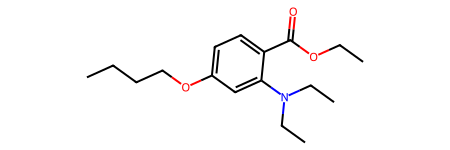

In [47]:
smiles = row.smiles
y_pred = row.y_pred
fE_ev = row.fragExplainer_expected_value
fE_result = row.fragExplainer_result
shap_ev = row.shap_expected_value
shap_result = row.shap_result
atom_id_to_bits = row.atom_id_to_bits
frag_to_atom_ids = row.frag_to_atom_ids

MolFromSmiles(row.smiles)

In [48]:
# check properties
assert np.allclose(np.sum([v for v in fE_result.values()]) + fE_ev, y_pred)
assert np.allclose(shap_ev + shap_result.sum(), y_pred)

# Visualize using fragExplainer output

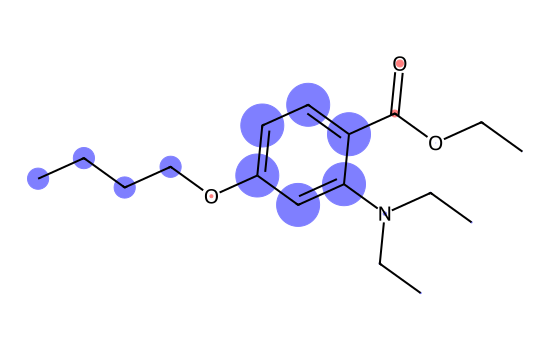

In [49]:
contributions = get_atom_contribution_from_result_dict(smiles=smiles,
                                                        results_dict=fE_result,
                                                        frag_to_atom_ids=frag_to_atom_ids)

visualize_contributions(smiles=smiles,
                        contributions=contributions,
                        scale=0.3)

# Visualizing using SHAP output

# Converting SHAP output to fragExplainer output